In [1]:

import operator
from typing import Annotated, Literal

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, \
    SystemMessage
from langchain_core.messages import ToolMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.types import Send
from langgraph_supervisor import create_supervisor
from pydantic import BaseModel, Field
from typing_extensions import TypedDict



In [2]:
_ = load_dotenv()
parser = StrOutputParser()
llm = init_chat_model("deepseek-chat", temperature=0.7, max_tokens=2000)

In [15]:
@tool
def compute_accuracy(correct: int, total: int) -> str:
    """Compute the classification accuracy given correct predictions and total samples."""
    if total == 0:
        return "Error: total cannot be zero."
    return f"Accuracy: {correct / total * 100:.2f}%"


@tool
def estimate_parameters(layers: list[int]):
    """Estimate the number of trainable parameters in a neural network."""
    if len(layers) < 2:
        return "Error: need at least an input and output layer."
    total = sum(layers[i] * layers[i + 1] for i in range(len(layers) - 1))

    return f"Estimated parameters: {total:,}"


@tool
def describe_split(total: int, train_pct: float, val_pct: float):
    """Describe a train/val/test split given total samples and percentages."""
    if not (0 < train_pct + val_pct < 1):
        return "Error: train_pct + val_pct must be between 0 and 1."
    train = int(total * train_pct)
    val = int(total * val_pct)
    test = total - train - val
    return f"Train: {train}, Val: {val}, Test: {test}"


@tool
def compute_f1(precision: float, recall: float) -> str:
    """Compute the F1 score given precision and recall values between 0 and 1."""
    if precision + recall == 0:
        return "F1 score: 0.0 (both precision and recall are zero)"
    f1 = 2 * precision * recall / (precision + recall)
    return f"F1 score: {f1:.4f}"


agent = create_agent(model=llm, tools=[compute_accuracy, estimate_parameters, describe_split, compute_f1],
                     system_prompt="You are an ML assistant. Use tools to help answer questions about models and datasets.")


def run_query(query: str) -> None:
    result = agent.invoke({"messages": [HumanMessage(content=query)]})
    print(f"Q: {query}")
    print(f"A: {result['messages'][-1].content}\n")


def run_trace(query: str) -> None:
    result = agent.invoke({"messages": [HumanMessage(content=query)]})
    print(f"Trace: {query!r}\n{'=' * 50}")
    for i, msg in enumerate(result["messages"]):
        label = type(msg).__name__
        print(f"\n[{i}] {label}")
        if isinstance(msg, HumanMessage):
            print(f"  {msg.content}")
        elif isinstance(msg, AIMessage):
            for tc in msg.tool_calls:
                print(f"  -> {tc['name']}({tc['args']})")
            if not msg.tool_calls:
                print(f"  {msg.content}")
        elif isinstance(msg, ToolMessage):
            print(f"  [{msg.name}] {msg.content}")



In [10]:
run_query("My model got 87 out of 120 predictions right. What's the accuracy?")


Q: My model got 87 out of 120 predictions right. What's the accuracy?
A: Your model achieved an accuracy of **72.50%** (87 correct out of 120 predictions).



In [11]:
run_query("How many parameters does a network with layers [784, 256, 128, 10] have?")


Q: How many parameters does a network with layers [784, 256, 128, 10] have?
A: A network with layers [784, 256, 128, 10] has approximately **234,752 trainable parameters**.

Here's the breakdown of how that's calculated:

- **Layer 1 (784 → 256):** 784 × 256 = 200,704 weights + 256 biases = **200,960**
- **Layer 2 (256 → 128):** 256 × 128 = 32,768 weights + 128 biases = **32,896**
- **Layer 3 (128 → 10):** 128 × 10 = 1,280 weights + 10 biases = **1,290**

**Total:** 200,960 + 32,896 + 1,290 = **234,752** parameters.



In [16]:
run_query("Precision is 0.82 and recall is 0.76. What's the F1 score?")

Q: Precision is 0.82 and recall is 0.76. What's the F1 score?
A: The F1 score is **0.7889** (or approximately **0.79**).

This is calculated using the formula:

\[
F1 = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}} = 2 \times \frac{0.82 \times 0.76}{0.82 + 0.76} = 2 \times \frac{0.6232}{1.58} \approx 0.7889
\]



In [17]:
run_trace(
    "I have 10000 samples. Split 70/15/15. "
    "Then tell me the F1 if precision=0.91 and recall=0.88."
)

Trace: 'I have 10000 samples. Split 70/15/15. Then tell me the F1 if precision=0.91 and recall=0.88.'

[0] HumanMessage
  I have 10000 samples. Split 70/15/15. Then tell me the F1 if precision=0.91 and recall=0.88.

[1] AIMessage
  -> describe_split({'total': 10000, 'train_pct': 70, 'val_pct': 15})

[2] ToolMessage
  [describe_split] Error: train_pct + val_pct must be between 0 and 1.

[3] AIMessage
  -> describe_split({'total': 10000, 'train_pct': 0.7, 'val_pct': 0.15})

[4] ToolMessage
  [describe_split] Train: 7000, Val: 1500, Test: 1500

[5] AIMessage
  -> compute_f1({'precision': 0.91, 'recall': 0.88})

[6] ToolMessage
  [compute_f1] F1 score: 0.8947

[7] AIMessage
  Here are the results:

**Train/Val/Test Split:**
- Total samples: 10,000
- Training: **7,000** (70%)
- Validation: **1,500** (15%)
- Test: **1,500** (15%)

**F1 Score:**
- Precision = 0.91
- Recall = 0.88
- **F1 = 0.8947** (or **89.47%**)

The F1 is calculated as the harmonic mean: \( F1 = 2 \times \frac{precision \ti

In [20]:
@tool
def compute_accuracy(correct: int, total: int) -> str:
    """Compute classification accuracy."""
    if total == 0:
        return "Error: total cannot be zero."
    return f"Accuracy: {correct / total * 100:.2f}%"


@tool
def compute_f1(precision: float, recall: float) -> str:
    """Compute the F1 score."""
    if precision + recall == 0:
        return "F1 score: 0.0"
    f1 = 2 * precision * recall / (precision + recall)
    return f"F1 score: {f1:.4f}"


@tool
def estimate_parameters(layers: list[int]) -> str:
    """Estimate trainable parameters in a dense network."""
    if len(layers) < 2:
        return "Error: need at least input and output layer."
    total = sum(
        layers[i] * layers[i + 1] + layers[i + 1]
        for i in range(len(layers) - 1)
    )
    return f"Estimated parameters: {total:,}"


class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


tools = [compute_accuracy, compute_f1, estimate_parameters]
llm_with_tools = llm.bind_tools(tools)
tool_node = ToolNode(tools)


def agent_node(state: AgentState) -> dict:
    """LLM decides what to do next."""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


def should_continue(state: AgentState) -> str:
    """Route: if LLM called a tool, go to tools. Otherwise end."""
    last_message = state["messages"][-1]
    if not hasattr(last_message, "tool_calls") or not last_message.tool_calls:
        return "end"
    return "tools"


graph = StateGraph(AgentState)
graph.add_node("agent", agent_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "agent")
graph.add_conditional_edges("agent", should_continue, {"tools": "tools", "end": END})
graph.add_edge("tools", "agent")

agent = graph.compile()


def run_query(query: str) -> None:
    result = agent.invoke({"messages": [HumanMessage(content=query)]})
    print(f"Q: {query}")
    print(f"A: {result['messages'][-1].content}\n")


if __name__ == "__main__":
    run_query("My model got 87 out of 120 predictions right. What's the accuracy?")
    run_query("Precision is 0.82 and recall is 0.76. What's the F1 score?")
    run_query("How many parameters does a network with layers [784, 256, 128, 10] have?")

Q: My model got 87 out of 120 predictions right. What's the accuracy?
A: The accuracy of your model is **72.50%** (87 correct out of 120 total predictions).

Q: Precision is 0.82 and recall is 0.76. What's the F1 score?
A: The F1 score is **0.7889** (or approximately **0.79**).

The calculation is:
- F1 = 2 × (precision × recall) / (precision + recall)
- F1 = 2 × (0.82 × 0.76) / (0.82 + 0.76)
- F1 = 2 × 0.6232 / 1.58
- F1 = 1.2464 / 1.58
- F1 ≈ 0.7889

Q: How many parameters does a network with layers [784, 256, 128, 10] have?
A: The network with layers [784, 256, 128, 10] has **235,146** trainable parameters.

Here's the breakdown:
- **Layer 1 (784 → 256):** 784 × 256 = 200,704 weights + 256 biases = 200,960
- **Layer 2 (256 → 128):** 256 × 128 = 32,768 weights + 128 biases = 32,896
- **Layer 3 (128 → 10):** 128 × 10 = 1,280 weights + 10 biases = 1,290

**Total:** 200,960 + 32,896 + 1,290 = **235,146**



In [21]:
run_trace(
    "I have 10000 samples. Split 70/15/15. "
    "Then tell me the F1 if precision=0.91 and recall=0.88."
)

Trace: 'I have 10000 samples. Split 70/15/15. Then tell me the F1 if precision=0.91 and recall=0.88.'

[0] HumanMessage
  I have 10000 samples. Split 70/15/15. Then tell me the F1 if precision=0.91 and recall=0.88.

[1] AIMessage
  -> compute_f1({'precision': 0.91, 'recall': 0.88})

[2] ToolMessage
  [compute_f1] F1 score: 0.8947

[3] AIMessage
  Here are the results:

**Dataset Split (70/15/15 of 10,000 samples):**
- Training: **7,000 samples**
- Validation: **1,500 samples**
- Test: **1,500 samples**

**F1 Score:**
- Precision = 0.91, Recall = 0.88
- **F1 = 0.8947** (or approximately **89.47%**)


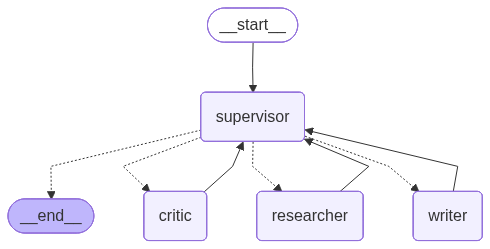

In [23]:
@tool
def gather_facts(topic: str) -> str:
    """Gather key facts and information about a topic for a blog post."""
    return (
        f"Key facts about '{topic}': "
        "1. Growing adoption across industries. "
        "2. Measurable improvements in efficiency and outcomes. "
        "3. Ongoing ethical and regulatory discussions. "
        "4. Backed by peer-reviewed research and case studies."
    )


@tool
def write_blog_post(research_notes: str, tone: str = "professional") -> str:
    """Draft a blog post from research notes in a given tone."""
    return (
        f"[Draft - {tone} tone]\n"
        f"Introduction based on: {research_notes[:80]}...\n"
        "Body: Explores key points with supporting evidence.\n"
        "Conclusion: Call to action for readers."
    )


@tool
def review_content(content: str) -> str:
    """Review blog post content and return structured feedback."""
    return (
        "Review complete.\n"
        "Strengths: Clear structure, good use of evidence.\n"
        "Improvements: Add a concrete example in section 2, "
        "strengthen the conclusion with a specific statistic.\n"
        "Verdict: Needs minor revision before publishing."
    )


researcher = create_agent(
    model=llm,
    tools=[gather_facts],
    name="researcher",
    system_prompt=(
        "You are a research specialist. "
        "Your only job is to gather facts and information on the given topic. "
        "Be thorough and concise. Always use the gather_facts tool."
    ),
)

writer = create_agent(
    model=llm,
    tools=[write_blog_post],
    name="writer",
    system_prompt=(
        "You are a writing specialist. "
        "Use the research provided to draft a clear, engaging blog post. "
        "Always use the write_blog_post tool. Incorporate any critic feedback you see."
    ),
)

critic = create_agent(
    model=llm,
    tools=[review_content],
    name="critic",
    system_prompt=(
        "You are a quality critic. "
        "Review the most recent draft objectively using the review_content tool. "
        "If the work meets quality standards, say APPROVED. "
        "Otherwise give specific, actionable feedback."
    ),
)

workflow = create_supervisor(
    agents=[researcher, writer, critic],
    model=llm,
    prompt=(
        "You are a content team supervisor managing three specialists: "
        "researcher, writer, and critic.\n\n"
        "Follow this workflow:\n"
        "1. Send the task to researcher first to gather facts.\n"
        "2. Send research output to writer to draft the post.\n"
        "3. Send the draft to critic for review.\n"
        "4. If critic requests changes, send back to writer.\n"
        "5. When critic says APPROVED, the task is complete.\n\n"
        "Delegate clearly. Do not do the work yourself."
    ),
)

agent = workflow.compile()

agent

In [24]:

def run(task: str) -> None:


result = agent.invoke({
    "messages": [{"role": "user", "content": task}]
})
print("\nFinal output:")
print(result["messages"][-1].content)

run("Write a short blog post about the benefits of AI in healthcare.")


Final output:
I'll incorporate those edits now.

Here is the final, polished version:

---

# The Healing Power of AI: How Artificial Intelligence is Transforming Healthcare

Artificial intelligence is no longer a futuristic concept — it's actively reshaping the healthcare landscape today. From faster diagnoses to personalized treatment plans, AI is helping clinicians save lives, reduce costs, and improve patient outcomes. Here are some of the key benefits.

## 1. Faster, More Accurate Diagnoses
AI-powered tools, particularly in medical imaging, can analyze X-rays, MRIs, and CT scans with remarkable speed and precision. Studies show that AI can detect abnormalities — such as early-stage tumors — sometimes even more accurately than the human eye. This means earlier intervention and better prognoses for patients.

## 2. Accelerating Drug Discovery
Traditional drug development is notoriously slow and expensive. AI is changing that by sifting through massive datasets to identify potential

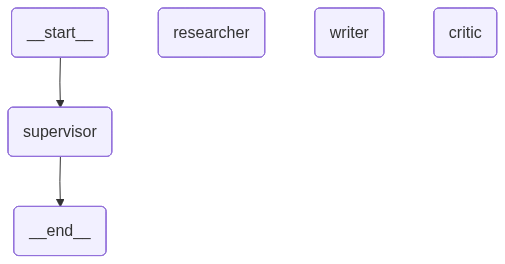

In [30]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]
    next_agent: str


class Route(BaseModel):
    next: Literal["researcher", "writer", "critic", "FINISH"] = Field(
        description="Which agent to call next, or FINISH if done.")
    reasoning: str = Field(description="Why this agent was chosen.")


router_llm = llm.with_structured_output(Route)
SUPERVISOR_PROMPT = """You are a supervisor managing three specialists:
- researcher: gathers facts
- writer: drafts content using research, incorporates critic feedback
- critic: reviews drafts and says APPROVED when quality is good

Workflow: researcher -> writer -> critic -> (writer if changes needed) -> FINISH"""


def supervisor(state: State) -> dict:
    decision = router_llm.invoke([SystemMessage(content=SUPERVISOR_PROMPT)] + state["messages"])
    return {
        "next_agent": decision.next,
        "messages": [AIMessage(content=f"[Supervisor -> {decision.next}] {decision.reasoning}")]
    }


def route(state: State):
    return END if state["next_agent"] == "FINISH" else state["next_agent"]


def researcher(state: State) -> dict:
    task = next(m.content for m in state["messages"] if isinstance(m, HumanMessage))
    response = llm.invoke([
        SystemMessage(content="You are a researcher. Gather relevant facts concisely."),
        HumanMessage(content=f"Research: {task}"),
    ])
    return {"messages": [AIMessage(content=f"[Researcher] {response.content}")]}


def writer(state: State) -> dict:
    context = "\n".join(m.content for m in state["messages"][-5:])
    response = llm.invoke([
        SystemMessage(content=(
            "You are a writer. Draft clear, engaging content from research. "
            "Incorporate any critic feedback you see in the context."
        )),
        HumanMessage(content=f"Write based on:\n{context}"),
    ])
    return {"messages": [AIMessage(content=f"[Writer] {response.content}")]}


def critic(state: State) -> dict:
    context = "\n".join(m.content for m in state["messages"][-3:])
    response = llm.invoke([
        SystemMessage(content=(
            "You are a critic. Review the draft objectively. "
            "Say APPROVED if it meets quality standards, "
            "otherwise give specific actionable feedback."
        )),
        HumanMessage(content=f"Review:\n{context}"),
    ])
    return {"messages": [AIMessage(content=f"[Critic] {response.content}")]}


graph = StateGraph(State)
graph.add_node("supervisor", supervisor)
graph.add_node("researcher", researcher)
graph.add_node("writer", writer)
graph.add_node("critic", critic)

graph.set_entry_point("supervisor")
graph.add_conditional_edges("supervisor", route)
graph.add_edge("researcher", "supervisor")
graph.add_edge("writer", "supervisor")
graph.add_edge("critic", "supervisor")

agent = graph.compile()
agent

In [31]:

result = agent.invoke({
    "messages": [HumanMessage(content=(
        "Write a short blog post about the benefits of AI in healthcare."
    ))],
    "next_agent": "",
})

print("\nConversation:")
for msg in result["messages"]:
    if isinstance(msg, AIMessage):
        print(f"\n{msg.content[:200]}{'...' if len(msg.content) > 200 else ''}")

print("\nFinal output:")
for msg in reversed(result["messages"]):
    if isinstance(msg, AIMessage) and "[Writer]" in msg.content:
        print(msg.content.replace("[Writer] ", ""))
        break


Conversation:

[Supervisor -> researcher] Starting the workflow. First, the researcher needs to gather facts about the benefits of AI in healthcare.

[Researcher] **Title: How AI is Quietly Revolutionizing Healthcare**

Artificial intelligence is no longer a futuristic concept—it’s already saving lives. Here are three concrete ways AI is transformi...

[Supervisor -> writer] Researcher has gathered key facts on AI in healthcare: faster diagnoses, personalized treatment, and predictive analytics. Now passing to the writer to draft the blog post.

[Writer] **Title: How AI is Quietly Revolutionizing Healthcare**

Artificial intelligence is no longer a futuristic concept—it’s already saving lives. Here are three concrete ways AI is transforming m...

[Supervisor -> critic] Writer has produced a draft blog post based on the researcher's facts. Now the critic should review it for quality, clarity, and completeness.

[Critic] APPROVED

The draft is clear, concise, and well-structured. It eff

In [9]:
# Agent Handoffs
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    next_agent: str


class Route(BaseModel):
    next: Literal["sales", "support", "billing", "end"] = Field(
        description="Which specialist to route to, or end if answerable directly"
    )
    context: str = Field(description="Key context summary to pass to the specialist.")


router_llm = llm.with_structured_output(Route)

TRIAGE_PROMPT = """You are a customer service triage agent. Route to:
- sales: product questions, purchases, upgrades
- support: technical issues, bugs, how-to questions
- billing: payments, invoices, refunds
- end: simple questions you can answer directly"""


def triage(state: State) -> dict:
    decision = router_llm.invoke(
        [SystemMessage(content=TRIAGE_PROMPT)] + state["messages"]
    )
    return {
        "next_agent": decision.next,
        "messages": [AIMessage(content=f"[Triage -> {decision.next}] {decision.context}")]
    }


def route(state: State) -> str:
    return END if state["next_agent"] == "end" else state["next_agent"]


SPECIALIST_PROMPTS = {
    "sales": (
        "You are a sales specialist. "
        "Help with product questions and purchases. Be helpful, not pushy."
    ),
    "support": (
        "You are a technical support specialist. "
        "Help with technical issues. Be patient and step-by-step."
    ),
    "billing": (
        "You are a billing specialist. "
        "Help with payments and refunds. Be clear about policies."
    ),
}


def make_specialist(name: str):
    def node(state: State) -> dict:
        response = llm.invoke([
                                  SystemMessage(content=SPECIALIST_PROMPTS[name]),
                              ] + state["messages"])
        return {"messages": [AIMessage(content=f"[{name.capitalize()}] {response.content}")]}

    node.__name__ = name
    return node


graph = StateGraph(State)
graph.add_node("triage", triage)
graph.add_node("sales", make_specialist("sales"))
graph.add_node("support", make_specialist("support"))
graph.add_node("billing", make_specialist("billing"))

graph.set_entry_point("triage")
graph.add_conditional_edges("triage", route, {
    "sales": "sales",
    "support": "support",
    "billing": "billing",
    END: END,
})

app = graph.compile()


def run(query: str) -> None:
    result = app.invoke({
        "messages": [HumanMessage(content=query)],
        "next_agent": "",
    })
    print(f"Customer: {query}")
    for msg in result["messages"]:
        if isinstance(msg, AIMessage):
            print(f"  {msg.content[:150]}")
        print("-" * 50)

In [10]:

queries = [
    "My app keeps crashing when I try to upload photos",
    "I want to upgrade to the premium plan",
    "I was charged twice for my subscription",
    "What time do you close?",
]
for q in queries:
    run(q)

Customer: My app keeps crashing when I try to upload photos
--------------------------------------------------
  [Triage -> support] User reports app crashes when attempting to upload photos. Likely a technical issue/bug that needs investigation.
--------------------------------------------------
  [Support] I'm sorry to hear the app is crashing when you try to upload photos. Let's work through this step by step to figure out what's going on.

Fi
--------------------------------------------------
Customer: I want to upgrade to the premium plan
--------------------------------------------------
  [Triage -> sales] Customer wants to upgrade to the premium plan.
--------------------------------------------------
  [Sales] That sounds like a great move! The premium plan gives you access to advanced features like priority support, more storage, and additional inte
--------------------------------------------------
Customer: I was charged twice for my subscription
---------------------------

In [11]:
import operator
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END


# Main state – holds the query, the list of perspectives, aggregated results, and final synthesis
class OverallState(TypedDict):
    query: str
    perspectives: list[str]
    results: Annotated[list, operator.add]  # auto‑merges all branch outputs
    synthesis: str


# State passed to each parallel branch – only the data it needs
class PerspectiveState(TypedDict):
    query: str
    perspective: str


def generate_perspectives(state: OverallState) -> dict:
    """Decide how many and which perspectives to research (dynamic fan‑out)."""
    resp = llm.invoke([
        SystemMessage("You are a research coordinator. Generate 3‑5 diverse perspectives for the given topic."),
        HumanMessage(f"Generate perspectives for: {state['query']}")
    ])
    # Simple parsing – you could use structured output for robustness
    perspectives = [p.strip("-• ") for p in resp.content.split("\n") if p.strip()]
    return {"perspectives": perspectives[:5]}  # cap at 5


def research_perspective(state: PerspectiveState) -> dict:
    """Single perspective research – runs in parallel for each perspective."""
    resp = llm.invoke([
        SystemMessage(
            f"You are an expert researcher. Provide deep insights from the '{state['perspective']}' perspective."),
        HumanMessage(f"Research this topic from {state['perspective']} perspective: {state['query']}")
    ])
    # Each branch appends one result – operator.add will collect them
    return {"results": [f"[{state['perspective']}]\n{resp.content}"]}


def synthesize(state: OverallState) -> dict:
    """Reduce step – combines all parallel outputs."""
    combined = "\n\n---\n\n".join(state["results"])
    resp = llm.invoke([
        SystemMessage("You are an expert synthesizer. Combine multiple perspectives into a cohesive analysis."),
        HumanMessage(f"Synthesise these perspectives on '{state['query']}':\n\n{combined}")
    ])
    return {"synthesis": resp.content}


# Conditional edge – returns a list of Send objects
def continue_to_research(state: OverallState):
    return [Send("research_perspective", {"query": state["query"], "perspective": p})
            for p in state["perspectives"]]


# Build the graph
builder = StateGraph(OverallState)
builder.add_node("generate_perspectives", generate_perspectives)
builder.add_node("research_perspective", research_perspective)
builder.add_node("synthesize", synthesize)

builder.add_edge(START, "generate_perspectives")
builder.add_conditional_edges("generate_perspectives", continue_to_research, ["research_perspective"])
# Once all parallel branches finish, the edge to "synthesize" automatically fires
builder.add_edge("research_perspective", "synthesize")
builder.add_edge("synthesize", END)

app = builder.compile()

if __name__ == "__main__":
    result = app.invoke({
        "query": "The future of remote work",
        "perspectives": [],
        "results": [],
        "synthesis": ""
    })
    print(result["synthesis"])

Based on the five perspectives provided, here is a synthesized analysis of the future of remote work, framed as a contested landscape shaped by a central tension: **the clash between organizational efficiency/control and individual autonomy/well-being.**

### The Central Tension: The "Strategic Amphibian" vs. The "Always-On" Trap

The future is not a single destination but a battleground between two competing visions of what "work" should be.

- **The Corporate Strategist (Perspective 2) and the Hybrid Optimist (Perspective 1)** envision the "Strategic Amphibian"—a company equally adept at operating in physical and digital environments. Their goal is to leverage hybrid for **talent arbitrage, cost reduction, and output-based productivity**. The office becomes a "destination" for high-bandwidth collaboration, while remote time is a sanctuary for deep focus. The risk is that this model, if poorly managed, creates a "two-class" system where remote workers are second-class citizens and "pr

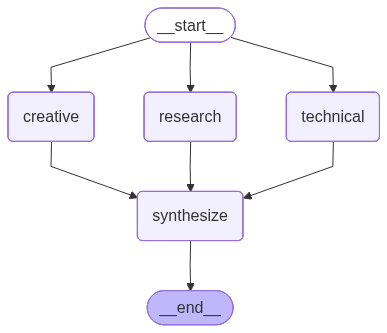

In [14]:
# Parallel Agents

class ParallelState(TypedDict):
    query: str
    research_result: str
    creative_result: str
    technical_result: str
    final_synthesis: str


def _make_chain(system: str):
    prompt = ChatPromptTemplate.from_messages([("system", system), ("human", "{query}")])
    return prompt | llm | parser


_research_chain = _make_chain(
    "You are an academic researcher. Provide factual, well-sourced information."
)
_creative_chain = _make_chain(
    "You are a creative thinker. Provide novel perspectives and ideas."
)
_technical_chain = _make_chain(
    "You are a technical analyst. Provide practical, implementation-focused insights."
)
_synthesis_chain = _make_chain(
    "You are an expert synthesizer. Combine multiple perspectives into coherent insights."
)


async def research_node(state: ParallelState):
    result = await _research_chain.ainvoke({"query": state["query"]})
    return {"research_result": result}


async def creative_node(state: ParallelState) -> dict:
    result = await _creative_chain.ainvoke({"query": state["query"]})
    return {"creative_result": result}


async def technical_node(state: ParallelState) -> dict:
    result = await _technical_chain.ainvoke({"query": state["query"]})
    return {"technical_result": result}


async def synthesize_node(state: ParallelState) -> dict:
    synthesis_query = (
        f"Synthesize these three perspectives into a comprehensive response:\n\n"
        f"RESEARCH: {state['research_result']}\n\n"
        f"CREATIVE: {state['creative_result']}\n\n"
        f"TECHNICAL: {state['technical_result']}\n\n"
        f"Create a unified, well-structured response."
    )
    result = await _synthesis_chain.ainvoke({"query": synthesis_query})
    return {"final_synthesis": result}


g = StateGraph(ParallelState)
g.add_node("research", research_node)
g.add_node("creative", creative_node)
g.add_node("technical", technical_node)
g.add_node("synthesize", synthesize_node)

g.add_edge(START, "research")
g.add_edge(START, "creative")
g.add_edge(START, "technical")

g.add_edge("research", "synthesize")
g.add_edge("creative", "synthesize")
g.add_edge("technical", "synthesize")

g.set_finish_point("synthesize")
app = g.compile()
app

In [17]:

result = await app.ainvoke({"query": "The future of remote work"})

print("=== Parallel Fan-out Demo ===\n")
print(f"[Research]\n{result['research_result'][:300]}...\n")
print(f"[Creative]\n{result['creative_result'][:300]}...\n")
print(f"[Technical]\n{result['technical_result'][:300]}...\n")
print("=" * 50)
print(f"[Synthesised]\n{result['final_synthesis']}")

=== Parallel Fan-out Demo ===

[Research]
Here is a comprehensive, evidence-based analysis of the future of remote work, drawing on academic research, industry data, and expert forecasts.

### Executive Summary

The future of remote work is not a simple binary of "return to office" (RTO) vs. "fully remote." Instead, it is evolving into a **...

[Creative]
The future of remote work will likely transcend the current "Zoom grid" and "asynchronous Slack" model, evolving into something more fluid, intentional, and deeply integrated with how we live. Here are several novel perspectives on what that future could look like:

### 1. The Rise of "Fluid Co-Loca...

[Technical]
The future of remote work is not about a binary return-to-office vs. fully remote decision. It is about **asynchronous specialization** and **operational intentionality**. Here is the practical, implementation-focused breakdown of where remote work is headed.

### 1. The Death of "Remote-First" as a...

[Synthesised]
Based 

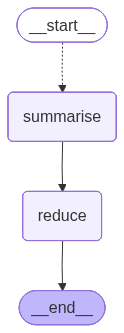

In [21]:
# Parallelization using Send API
class MapReduceState(TypedDict):
    documents: list[str]
    summaries: Annotated[list[str], operator.add]
    final_summary: str


class DocumentState(TypedDict):
    document: str
    summaries: Annotated[list[str], operator.add]


_summary_chain = _make_chain("Summarise this document in 2-3 sentences.")
_reduce_chain = _make_chain(
    "Combine these summaries into one coherent overview."
)


# Fan out each document to its own summarise_node call
def dispatch_documents(state: MapReduceState) -> list[Send]:
    return [Send("summarise", {"document": doc}) for doc in state["documents"]]


async def summarise_node(state: DocumentState) -> dict:
    summary = await _summary_chain.ainvoke({"query": state["document"]})
    return {"summaries": [summary]}  # Append to the parent's summaries via operator.add


async def reduce_node(state: MapReduceState):
    combined = "\n\n".join(f"Summary {i + 1}: {s}" for i, s in enumerate(state["summaries"]))
    result = await _reduce_chain.ainvoke({"query": combined})
    return {"final_summary": result}


graph = StateGraph(MapReduceState)
graph.add_node("summarise", summarise_node)
graph.add_node("reduce", reduce_node)

graph.add_conditional_edges(START, dispatch_documents, ["summarise"])
graph.add_edge("summarise", "reduce")
graph.add_edge("reduce", END)

app = graph.compile()
app


In [25]:
documents = [
    "Zero-Inflated Gamma Generalized Linear Mixed Models (GLMMs) effectively handle continuous, positive data characterized by an excess of exact zeros.",
    "Bayesian Structural Time Series (BSTS) provides a robust framework for forecasting by utilizing state-space models and accommodating prior distributions.",
    "In multivariate non-parametric analysis, copulas isolate marginal distributions from the underlying dependence structure of joint variables."
]

result = await app.ainvoke({"documents": documents, "summaries": [], "final_summary": ""})
print("\n=== Send API Map-Reduce Demo ===\n")
print("Individual summaries:")
for i, s in enumerate(result["summaries"]):
    print(f"  {i + 1}. {s}")
print(f"\nCombined summary:\n{result['final_summary']}")


=== Send API Map-Reduce Demo ===

Individual summaries:
  1. Zero-Inflated Gamma GLMMs are statistical models designed for continuous positive data that contain an unusually high number of exact zero values. They combine a gamma distribution for the positive values with a separate component to model the excess zeros. This approach allows for accurate analysis of such mixed data structures.
  2. Bayesian Structural Time Series (BSTS) is a forecasting method that uses state-space models to capture trends, seasonality, and other patterns, while incorporating prior knowledge through Bayesian inference. This approach allows for robust predictions even with limited or noisy data.
  3. Copulas allow for the separation of marginal distributions from the dependence structure in multivariate non-parametric analysis. This enables the modeling of complex dependencies between variables independently of their individual distributions. Essentially, copulas provide a way to understand and quantify ho

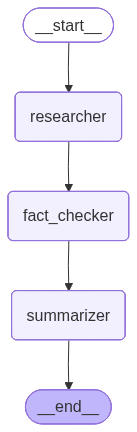

In [29]:
# Message Passing
class MessagePassingState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


_researcher_chain = ChatPromptTemplate.from_messages(
    [("system", "You are a researcher. Answer the user's questions with 2-3 sentences of findings"),
     ("placeholder", "{messages}")]) | llm | parser

_fact_checker_chain = ChatPromptTemplate.from_messages(
    [("system",
      "You are a fact-checker. Validate or challenge the researcher's findings in the conversation. 2-3 sentences."),
     ("placeholder", "{messages}")]
)

_summarizer_chain = ChatPromptTemplate.from_messages(
    [("system",
      "You are a summarizer. Synthesise the researcher's findings and the fact-checker's review into a final 2-3 sentence summary."),
     ("placeholder", "{messages}")]
) | llm | parser


async def researcher_node(state: MessagePassingState) -> dict:
    result = await _researcher_chain.ainvoke({"messages": state["messages"]})
    return {"messages": [AIMessage(content=f"[RESEARCHER]: {result}", name="researcher")]}


async def fact_checker_node(state: MessagePassingState):
    result = await _researcher_chain.ainvoke({"messages": state["messages"]})
    return {"messages": [AIMessage(content=f"[FACT-CHECKER]: {result}", name="fact_checker")]}


async def summarizer_node(state: MessagePassingState) -> dict:
    result = await _summarizer_chain.ainvoke({"messages": state["messages"]})
    return {"messages": [AIMessage(content=f"[SUMMARY]: {result}", name="summarizer")]}


g = StateGraph(MessagePassingState)
g.add_node("researcher", researcher_node)
g.add_node("fact_checker", fact_checker_node)
g.add_node("summarizer", summarizer_node)
g.add_edge(START, "researcher")
g.add_edge("researcher", "fact_checker")
g.add_edge("fact_checker", "summarizer")
g.add_edge("summarizer", END)
app = g.compile()
app

In [30]:
result = await app.ainvoke({"messages": [HumanMessage(content="What are the main benefits of renewable energy?")]})
for msg in result["messages"]:
    if isinstance(msg, AIMessage):
        print(f"{msg.content}\n")

[RESEARCHER]: The main benefits of renewable energy include a significant reduction in greenhouse gas emissions, which helps mitigate climate change by replacing fossil fuels. It also enhances energy security by diversifying power sources and reducing dependence on imported fuels. Additionally, renewable energy creates jobs in manufacturing, installation, and maintenance, while often leading to lower long-term electricity costs due to minimal fuel expenses.

[FACT-CHECKER]: The main benefits of renewable energy include a significant reduction in greenhouse gas emissions, which helps combat climate change by displacing fossil fuels. It also enhances energy independence and security by diversifying power sources and reducing reliance on imported fuels. Additionally, renewable energy creates jobs in manufacturing and installation, while often lowering long-term electricity costs due to minimal fuel expenses.

[SUMMARY]: Renewable energy reduces greenhouse gas emissions to combat climate c

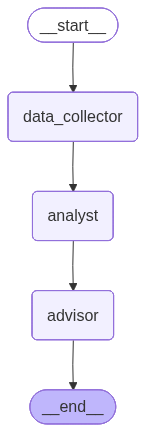

In [3]:
# Shared State
class DataPoints(BaseModel):
    points: list[dict] = Field(description="List of dicts with 'source' and 'finding' keys")


class AnalysisResult(BaseModel):
    analysis: str = Field(description="2-3 sentence analysis of the collected data")
    confidence_score: float = Field(description="Confidence from 0.0 to 1.0", ge=0.0, le=1.0)


class RecommendationResult(BaseModel):
    recommendations: list[str] = Field(description="3 actionable recommendations")


class SharedFieldsState(TypedDict):
    query: str
    raw_data: Annotated[list[dict], operator.add]
    analysis: str
    recommendations: list[str]
    confidence_score: float


_data_collector_llm = llm.with_structured_output(DataPoints)
_analyst_llm = llm.with_structured_output(AnalysisResult)
_advisor_llm = llm.with_structured_output(RecommendationResult)

_data_collector_chain = ChatPromptTemplate.from_messages([
    ("system", "You are a data collector. Produce 3 data points with 'source' and 'finding' keys for the given query."),
    ("human", "{query}")
]) | _data_collector_llm
_analyst_chain = ChatPromptTemplate.from_messages(
    [("system",
      "You are a data analyst. Analyse the collected data and return a brief analysis and a confidence score."),
     ("human", "Query: {query}\n\nData: {raw_data}")]
) | _analyst_llm
_advisor_chain = ChatPromptTemplate.from_messages(
    [("system",
      "You are a strategic advisor. Based on the analysis and confidence score, return 3 actionable recommendations."),
     ("human", "Query: {query}\nAnalysis: {analysis}\nConfidence: {confidence_score}")]
) | _advisor_llm


async def data_collector_node(state: SharedFieldsState):
    result = await _data_collector_chain.ainvoke({"query": state["query"]})
    return {"raw_data": result.points}


async def analyst_node(state: SharedFieldsState):
    result = await _analyst_chain.ainvoke({"query": state["query"], "raw_data": state["raw_data"]})
    return {"analysis": result.analysis, "confidence_score": result.confidence_score}


async def advisor_node(state: SharedFieldsState):
    result = await _advisor_chain.ainvoke(
        {"query": state["query"], "analysis": state["analysis"], "confidence_score": state["confidence_score"]})
    return {"recommendations": result.recommendations}


graph = StateGraph(SharedFieldsState)
graph.add_node("data_collector", data_collector_node)
graph.add_node("analyst", analyst_node)
graph.add_node("advisor", advisor_node)
graph.set_entry_point("data_collector")
graph.add_edge("data_collector", "analyst")
graph.add_edge("analyst", "advisor")
graph.set_finish_point("advisor")

app = graph.compile()
app

In [5]:
result = await app.ainvoke(
    {
        "query": "Should a small business invest in AI automation in 2026?",
        "raw_data": [],
        "analysis": "",
        "recommendations": [],
        "confidence_score": 0.0,
    }
)
print("=== Shared state ===\n")
print(f"Data collected: {len(result['raw_data'])} points")
for d in result["raw_data"]:
    print(f"  [{d.get('source', 'N/A')}] {d.get('finding', 'N/A')[:80]}...")
print(f"\nAnalysis: {result['analysis'][:200]}...")
print(f"Confidence: {result['confidence_score']:.2f}")
print("\nRecommendations:")
for i, rec in enumerate(result["recommendations"], 1):
    print(f"  {i}. {rec}")

=== Shared state ===

Data collected: 3 points
  [McKinsey Global Institute (2024) - 'The Economic Potential of Generative AI'] Small businesses that adopt AI automation can see a 10-20% reduction in operatio...
  [Gartner Hype Cycle for Emerging Technologies (2025)] By 2026, AI automation tools are projected to become more affordable and accessi...
  [U.S. Small Business Administration (SBA) Technology Report (2025)] Approximately 62% of small businesses that invested in AI automation in 2024-202...

Analysis: Based on the collected data, small businesses should consider investing in AI automation in 2026. McKinsey reports 10-20% operational cost reductions within the first year, Gartner projects tools beco...
Confidence: 0.82

Recommendations:
  1. Start with a targeted pilot program in one high-impact area (e.g., customer service chatbots or inventory management) to validate ROI before scaling across the business. This minimizes risk while capturing the 10-20% cost reduction potenti

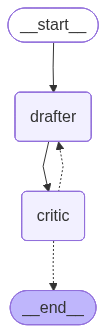

In [6]:
# Blackboard
# Shared workspace + message_history + iterative refinement
class BlackboardState(TypedDict):
    topic: str
    drafts: Annotated[list[str], operator.add]
    critiques: Annotated[list[str], operator.add]
    iteration: int
    is_approved: bool


class CriticDecision(BaseModel):
    approved: bool = Field(description="True if the draft is good enough to publish")
    feedback: str = Field(description="Specific, actionable feedback if not approved")


_drafter_chain = ChatPromptTemplate.from_messages([
    ("system",
     "You are a skilled writer. Write or revise a short paragraph (3-4 sentences) on the given topic. If feedback is provided, address it directly in your revision."),
    ("human", "Topic: {topic}\n\nPrevious draft: {draft}\n\nFeedback to address: {critique}"),
]) | llm | parser

_critic_chain = ChatPromptTemplate.from_messages([
    ("system",
     "You are a strict editor. Review the draft for clarity, accuracy, and engagement. Approve only if it is genuinely publication-ready."),
    ("human", "Topic: {topic}\nIteration: {iteration}\nDraft: {draft}"),
]) | llm.with_structured_output(CriticDecision)

MAX_ITERATIONS = 3


async def drafter_node(state: BlackboardState) -> dict:
    draft = await _drafter_chain.ainvoke({"topic": state["topic"],
                                          "draft": state["drafts"][-1] if state["drafts"] else "None yet",
                                          "critique": state["critiques"][-1] if state["critiques"] else "None", })
    return {
        "drafts": [draft],
        "messages": [AIMessage(content=f"[DRAFTER iter {state['iteration'] + 1}]: {draft}", name="drafter")],
        "iteration": state["iteration"] + 1,
    }


async def critic_node(state: BlackboardState):
    decision = await _critic_chain.ainvoke({
        "topic": state["topic"],
        "iteration": state["iteration"],
        "draft": state["drafts"][-1],
    })
    approved = decision.approved or state["iteration"] >= MAX_ITERATIONS
    result = {"is_approved": approved, "messages": [
        AIMessage(content=f"[CRITIC]: {'APPROVED' if approved else 'REVISION NEEDED'} - {decision.feedback}",
                  name="critic")]}
    if not approved:
        result["critiques"] = [decision.feedback]
    return result


def route_after_critic(state: BlackboardState) -> Literal["drafter", "__end__"]:
    return "__end__" if state["is_approved"] else "drafter"


graph = StateGraph(BlackboardState)
graph.add_node("drafter", drafter_node)
graph.add_node("critic", critic_node)
graph.set_entry_point("drafter")
graph.add_edge("drafter", "critic")
graph.add_conditional_edges("critic", route_after_critic, {"drafter": "drafter", "__end__": END})
app = graph.compile()
app

In [9]:
result = await app.ainvoke(
    {
        "messages": [],
        "topic": "Why LangGraph is great for building multi-agent systems",
        "drafts": [],
        "critiques": [],
        "iteration": 0,
        "is_approved": False,
    }
)

print("=== Blackboard ===\n")
print(f"Iterations: {result['iteration']}  |  Approved: {result['is_approved']}\n")

for msg in result.get("messages", []):
    if isinstance(msg, AIMessage):
        print(f"{msg.content}\n")

print(f"Final draft:\n{result['drafts'][-1]}")
d

=== Blackboard ===

Iterations: 1  |  Approved: True

Final draft:
LangGraph is an exceptional framework for building multi-agent systems because it provides fine-grained control over complex, cyclical workflows through its graph-based architecture. Unlike linear pipelines, it allows agents to communicate, loop, and conditionally route messages, enabling dynamic collaboration and error recovery. Its built-in state management ensures that each agent can access and update a shared context seamlessly, making coordination both scalable and maintainable. This makes LangGraph ideal for applications requiring adaptive, multi-step reasoning among specialized agents.


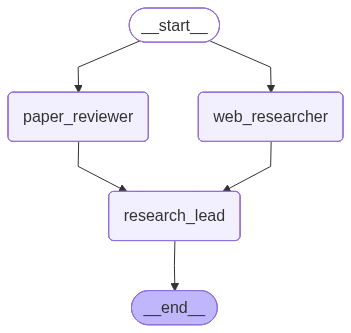

In [3]:
# Hierarchical agents
class TeamState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    department: str
    final_answer: str


class DepartmentRoute(BaseModel):
    department: Literal["research", "content", "analysis"] = Field(
        description="Which department should handle this request")
    reasoning: str = Field(description="Why this department was chosen")


_ceo_chain = ChatPromptTemplate.from_messages([("system",
                                                "You are the CEO supervisor. Analyze the user request and route it to the optimal department. Options:\n- 'research': For technical deep-dives, literature reviews, fact-finding, and academic investigation.\n- 'content': For generating articles, copywriting, summaries, and creative text orchestration.\n- 'analysis': For quantitative evaluation, logical deduplication, and strategic data decisions.\nOutput ONLY the JSON matching the schema."),
                                               ("placeholder", "{messages}")]) | llm.with_structured_output(
    DepartmentRoute)

_web_researcher_chain = ChatPromptTemplate.from_messages([("system",
                                                           "You are an elite web researcher. Extract verified facts, statistics, and raw data regarding the topic. Provide exactly 3-4 distinct bullet points using standard Markdown format. Avoid prose."),
                                                          ("placeholder", "{messages}")]) | llm | parser
_paper_reviewer_chain = ChatPromptTemplate.from_messages([("system",
                                                           "You are an academic peer reviewer. Evaluate technical depth, underlying methodology, and cite relevant structural frameworks. Provide exactly 3-4 high-density bullet points using Markdown."),
                                                          ("placeholder", "{messages}")]) | llm | parser
_research_lead_chain = ChatPromptTemplate.from_messages([("system",
                                                          "You are the Lead Principal Investigator. Synthesize the provided Web Research facts and Academic Review insights into a single, high-density cohesive paragraph. Do not include introductory phrases or conversational filler."),
                                                         ("placeholder", "{messages}")]) | llm | parser

_writer_chain = ChatPromptTemplate.from_messages([("system",
                                                   "You are a professional content engineer. Transform the available research data and conversation context into an engaging, publication-ready single paragraph. Maintain a sophisticated yet accessible tone."),
                                                  ("placeholder", "{messages}")]) | llm | parser
_editor_chain = ChatPromptTemplate.from_messages([("system",
                                                   "You are a chief copyeditor. Refine the provided draft for extreme clarity, syntactic flow, and brevity. Remove fluff and typos. Return ONLY the final polished text—no explanations or meta-commentary."),
                                                  ("placeholder", "{messages}")]) | llm | parser

_data_analyst_chain = ChatPromptTemplate.from_messages([("system",
                                                         "You are an expert data analyst. Evaluate the topic using precise quantitative reasoning, metrics, and trends. Output exactly 3-4 highly technical, data-driven insights in a structured Markdown list."),
                                                        ("placeholder", "{messages}")]) | llm | parser
_strategy_advisor_chain = ChatPromptTemplate.from_messages([("system",
                                                             "You are a senior strategic advisor. Review the quantitative data available in the conversation and synthesize exactly 3 discrete, actionable strategic recommendations. Focus on practical execution and impact."),
                                                            ("placeholder", "{messages}")]) | llm | parser


# Departmen 1: Research team subgraph
# Web Researcher and paper_reviewer fan out in parallel;
async def web_researcher_node(state: TeamState):
    result = await _web_researcher_chain.ainvoke({"messages": state["messages"]})
    return {"messages": [AIMessage(content=f"[WEB RESEARCHER]: {result}", name="web_researcher")]}


async def paper_reviewer_node(state: TeamState):
    result = await _paper_reviewer_chain.ainvoke({"messages": state["messages"]})
    return {"messages": [AIMessage(content=f"[PAPER REVIEWER]: {result}", name="paper_reviewer")]}


async def research_lead_node(state: TeamState):
    result = await _research_lead_chain.ainvoke({"messages": state["messages"]})
    return {"messages": [AIMessage(content=f"[RESEARCH LEAD]: {result}", name="research_lead")],
            "final_answer": result, }


def build_research_team() -> object:
    g = StateGraph(TeamState)
    g.add_node("web_researcher", web_researcher_node)
    g.add_node("paper_reviewer", paper_reviewer_node)
    g.add_node("research_lead", research_lead_node)
    # Fan-out: both researchers run in the same superstep
    g.add_edge(START, "web_researcher")
    g.add_edge(START, "paper_reviewer")
    # Fan-in: both must finish before the lead synthesises
    g.add_edge("web_researcher", "research_lead")
    g.add_edge("paper_reviewer", "research_lead")
    g.add_edge("research_lead", END)
    return g.compile()


research = build_research_team()
research

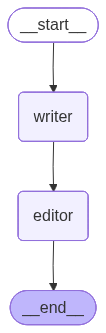

In [4]:
# Department 2: Content team subgraph
async def writer_node(state: TeamState):
    result = await _writer_chain.ainvoke({"messages": state["messages"]})
    return {"messages": [AIMessage(content=f"[WRITER]: {result}", name="writer")]}


async def editor_node(state: TeamState):
    result = await _editor_chain.ainvoke({"messages": state["messages"]})
    return {
        "messages": [AIMessage(content=f"[EDITOR]: {result}", name="editor")],
        "final_answer": result,
    }


def build_content_team() -> object:
    g = StateGraph(TeamState)
    g.add_node("writer", writer_node)
    g.add_node("editor", editor_node)
    g.add_edge(START, "writer")
    g.add_edge("writer", "editor")
    g.add_edge("editor", END)
    return g.compile()


build_content_team()


In [6]:
# Data Analysis Subgraph

async def data_analyst_node(state: TeamState) -> dict:
    result = await _data_analyst_chain.ainvoke({"messages": state["messages"]})
    return {"messages": [AIMessage(content=f"[DATA ANALYST]: {result}", name="data_analyst")]}


async def strategy_advisor_node(state: TeamState) -> dict:
    result = await _strategy_advisor_chain.ainvoke({"messages": state["messages"]})
    return {
        "messages": [AIMessage(content=f"[STRATEGY ADVISOR]: {result}", name="strategy_advisor")],
        "final_answer": result,
    }


def build_analysis_team() -> object:
    g = StateGraph(TeamState)
    g.add_node("data_analyst", data_analyst_node)
    g.add_node("strategy_advisor", strategy_advisor_node)
    g.add_edge(START, "data_analyst")
    g.add_edge("data_analyst", "strategy_advisor")
    g.add_edge("strategy_advisor", END)
    return g.compile()


In [13]:
async def ceo_node(state: TeamState):
    decision = await _ceo_chain.ainvoke({"messages": state["messages"]})
    return {"department": decision.department, "messages": [
        AIMessage(content=f"[CEO]: Routing to {decision.department} - {decision.reasoning}", name="ceo", )]}


def route_to_department(state: TeamState) -> Literal["research_team", "content_team", "analysis_team"]:
    mapping = {
        "research": "research_team",
        "content": "content_team",
        "analysis": "analysis_team",
    }
    return mapping.get(state["department"], "research_team")


def build_hierarchical_system() -> object:
    research_team = build_research_team()
    content_team = build_content_team()
    analysis_team = build_analysis_team()

    parent = StateGraph(TeamState)
    parent.add_node("ceo", ceo_node)
    # Compiled subgraphs drop in as regular nodes.
    parent.add_node("research_team", research_team)
    parent.add_node("content_team", content_team)
    parent.add_node("analysis_team", analysis_team)

    parent.add_edge(START, "ceo")
    parent.add_conditional_edges(
        "ceo",
        route_to_department,
        {
            "research_team": "research_team",
            "content_team": "content_team",
            "analysis_team": "analysis_team",
        },
    )
    parent.add_edge("research_team", END)
    parent.add_edge("content_team", END)
    parent.add_edge("analysis_team", END)

    return parent.compile()



In [14]:
system = build_hierarchical_system()
queries = [
    "What are the latest trends in large language models?",
    "Write a short blog introduction about AI agents",
    "Should my startup invest in building AI features this year?",
]

for query in queries:
    print(f"Query: {query}")
    print("-" * 50)

    result = await system.ainvoke(
        {"messages": [HumanMessage(content=query)], "department": "", "final_answer": ""}
    )

for msg in result["messages"]:
    if isinstance(msg, AIMessage) and msg.name == "ceo":
        print(f"  {msg.content}")

print(f"  Department: {result['department']}")
print(f"  Final: {result['final_answer'][:200]}...")
print("=" * 50 + "\n")

Query: What are the latest trends in large language models?
--------------------------------------------------
  [CEO]: Routing to research - The user is asking about the latest trends in large language models, which requires a technical deep-dive, fact-finding, and investigation into current developments in the field. This is a research-oriented question that fits the 'research' department's expertise.
  Department: research
  Final: The dominant trend in large language models is a paradigm shift from scaling model size during pre-training to optimizing inference-time compute, exemplified by techniques like chain-of-thought reason...

Query: Write a short blog introduction about AI agents
--------------------------------------------------
  [CEO]: Routing to content - The user is requesting a short blog introduction about AI agents, which is a creative writing task (generating content/copywriting). This falls under the 'content' department's responsibilities.
  Department: content
  F

In [5]:
llm = init_chat_model("deepseek-chat", temperature=0)
creative_llm = init_chat_model("deepseek-chat", temperature=0.7)


class SearchQueries(BaseModel):
    queries: list[str] = Field(
        min_length=3, max_length=3, description="Exactly 3 search queries covering different angles of the topic"
    )


class Finding(BaseModel):
    title: str = Field(description="Short descriptive title for this finding")
    detail: str = Field(description="1-2 sentence summary of the finding")
    source_query: str = Field(default="", description="The query that produced this finding")


class SearchResults(BaseModel):
    findings: list[Finding] = Field(description="2-3 findings from the search query", min_length=1)


class QualityReview(BaseModel):
    score: float = Field(ge=0.0, le=1.0, description="Quality score on completeness, clarity and actionability")
    feedback: str = Field(description="One specific, actionable sentence of improvement feedback")
    approved: bool = Field(description='True if score >= 0.7')


class ResearchState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    findings: Annotated[list[dict], operator.add]  # Finding.model_dump() dicts
    topic: str
    search_queries: list[str]
    analysis: str
    report: str
    quality_score: float
    quality_feedback: str
    iteration: int


class SearchTaskState(TypedDict):
    search_query: str
    findings: Annotated[list[dict], operator.add]


query_chain = llm.with_structured_output(SearchQueries)
search_chain = llm.with_structured_output(SearchResults)
review_chain = llm.with_structured_output(QualityReview)


async def supervisor(state: ResearchState):
    result = await query_chain.ainvoke(
        [SystemMessage(
            content="You are a research planner. Generate exactly 3 search query strings that cover meaningfully different angles of the topic: background/overview, recent developments and practical applications or challenges"),
            HumanMessage(content=f"Topic: {state['topic']}")]
    )
    queries = result.queries
    return {"search_queries": queries, "messages": [AIMessage(content=f"[SUPERVISOR]: {queries}", name="supervisor")]}


async def search_agent(state: SearchTaskState):
    query = state["search_query"]
    result = await search_chain.ainvoke(
        [SystemMessage(
            content="You are a research agent with broad knowledge. For the query, return 2-3 distinct, specific findings.Each finding needs a concise title and a 1-2 sentnece detail that a non-expert can understand"),
            HumanMessage(content=f"Query: {query}")]
    )
    findings = [f.model_copy(update={"source_query": query}).model_dump()
                for f in result.findings]
    return {"findings": findings}


async def search_agent_error_handler(error: Exception, state: SearchTaskState):
    query = state.get("search_query", "Unknown query")
    fallback = Finding(title=f"Search failed: {query}", detail=str(error), source_query=query)
    return {"findings": [fallback.model_dump()]}


async def analyst(state: ResearchState):
    findings_text = "\n".join(
        f"- [{f['source_query']}] {f['title']}: {f['detail']}"
        for f in state["findings"]
    )
    result = await llm.ainvoke(
        [SystemMessage(
            content=f"You are a senior research analyst. Synthesise the findings into 2-3 tight paragraphs:\nPara 1: Key themes and patterns\nPara2:Contradictions, gaps, or open questions\nPara3:The single most important insight and why it matters\nBe specific-name concrete examples from the findings"),
            HumanMessage(content=f"Topic: {state['topic']}\n\nFindings:\n{findings_text}")]
    )
    return {"analysis": result.content,
            "messages": [AIMessage(content=f"[ANALYST]: {result.content[:200]}...", name="analyst")]}


async def report_writer(state: ResearchState) -> dict:
    """Produce or revise a structured markdown research report."""
    revision_note = (
        f" Revision #{state['iteration']} — specifically address: {state['quality_feedback']}"
        if state["iteration"] > 0 and state.get("quality_feedback")
        else ""
    )

    resp = await creative_llm.ainvoke([
        SystemMessage(content=(
            f"You are a research report writer. Produce a markdown report with exactly these four sections in order: an Executive Summary of 2-3 sentences covering what was studied and the headline finding; Key Findings as a bulleted list where each item is grounded in the findings data; an Analysis of 1-2 paragraphs that avoids generic statements; and Recommendations consisting of exactly 3 numbered, concrete, actionable recommendations.{revision_note}"
        )),
        HumanMessage(content=(
                f"Topic: {state['topic']} Analysis: {state['analysis']} Findings sample: " +
                " ".join(f"{f['title']}: {f['detail']}" for f in state["findings"][:6])
        )),
    ])

    label = "revised" if state["iteration"] > 0 else "drafted"
    return {
        "report": resp.content,
        "messages": [AIMessage(content=f"[report_writer] Report {label}.", name="report_writer")],
    }


async def quality_checker(state: ResearchState):
    review = await review_chain.ainvoke(
        [SystemMessage(
            content="You are a quality reviewer. Score the report 0.0-1.0 across three dimensions: Completeness: does it address the topic thoroughly? Clarity: is it well-structured and easy to follow? Actionability: are the recommendations specific and implementable? Approve (True) if overall score >= 0.7. On iteration >= 2, approve unless the report is critically incomplete. Feedback must be one sentence naming the single most important fix"),
            HumanMessage(content=f"Topic: {state['topic']} Iteration: {state['iteration']} Report: {state['report']}")]
    )
    approved = review.approved or state["iteration"] >= 2
    return {
        "quality_score": review.score,
        "quality_feedback": review.feedback,
        "iteration": state["iteration"] + 1,
        "messages": [AIMessage(content=f"[quality_checker] {review.score:.2f} - "
                                       f"{'APPROVED' if approved else 'REVISION NEEDED'}: {review.feedback}",
                               name="quality_checker")]
    }


def dispatch_searches(state: ResearchState):
    return [Send("search_agent", {"search_query": q, "findings": []}) for q in state["search_queries"]]


def quality_gate(state: ResearchState):
    return "end" if state["quality_score"] >= 0.7 or state["iteration"] >= 2 else "report_writer"


def build_graph():
    g = StateGraph(ResearchState)

    g.add_node("supervisor", supervisor)
    g.add_node("search_agent", search_agent, error_handler=search_agent_error_handler)
    g.add_node("analyst", analyst)
    g.add_node("report_writer", report_writer)
    g.add_node("quality_checker", quality_checker)

    g.add_edge(START, "supervisor")
    g.add_conditional_edges("supervisor", dispatch_searches, ["search_agent"])
    g.add_edge("search_agent", "analyst")
    g.add_edge("analyst", "report_writer")
    g.add_edge("report_writer", "quality_checker")
    g.add_conditional_edges(
        "quality_checker",
        quality_gate,
        {"report_writer": "report_writer", "end": END},
    )

    return g.compile()


def initial_state(topic: str) -> ResearchState:
    return ResearchState(
        messages=[],
        topic=topic,
        search_queries=[],
        findings=[],
        analysis="",
        report="",
        quality_score=0.0,
        quality_feedback="",
        iteration=0,
    )


system = build_graph()

In [7]:
topic = "Best practices for building multi-agent AI Systems"

print(f"Streaming: {topic}\n")
async for step in system.astream(initial_state(topic), stream_mode="updates"):
    for node, update in step.items():
        extra = ""
        if "search_queries" in update and update["search_queries"]:
            extra = f" | queries={update['search_queries']}"
        elif "findings" in update and update["findings"]:
            extra = f" | +{len(update['findings'])} findings"
        elif "quality_score" in update:
            extra = f" | score={update['quality_score']:.2f}"
        print(f"  [{node}]{extra}")
print()

Streaming: Best practices for building multi-agent AI Systems

  [supervisor] | queries=['multi-agent AI systems architecture design patterns overview 2024', 'multi-agent AI systems latest research developments trends 2025', 'multi-agent AI systems implementation challenges best practices production']
  [search_agent] | +3 findings
  [search_agent] | +3 findings
  [search_agent] | +3 findings
  [analyst]
  [report_writer]
  [quality_checker] | score=0.85



In [8]:
print(f"Topic: {topic}\n")

result = await system.ainvoke(initial_state(topic))

print("Agent log:")
for msg in result["messages"]:
    if isinstance(msg, AIMessage):
        print(f"  {msg.content[:100]}")

print()
print(
    f"Findings: {len(result['findings'])}"
    f"  |  Score: {result['quality_score']:.2f}"
    f"  |  Iterations: {result['iteration']}"
)
print("\n" + "=" * 60)
print("FINAL REPORT")
print("=" * 60)
print(result["report"])

Topic: Best practices for building multi-agent AI Systems

Agent log:
  [SUPERVISOR]: ['multi-agent AI systems architecture design patterns overview 2024', 'multi-agent AI 
  [ANALYST]: **Key Themes and Patterns:** The dominant architectural pattern in 2024 is the orchestrat
  [report_writer] Report drafted.
  [quality_checker] 0.85 - APPROVED: Add concrete implementation examples or case studies to strengthe

Findings: 9  |  Score: 0.85  |  Iterations: 1

FINAL REPORT
# Report: Best Practices for Building Multi-Agent AI Systems

## Executive Summary
This report examines the current state of multi-agent AI system design, analyzing architectural patterns, frameworks, and protocols driving enterprise adoption in 2024-2025. The headline finding is that standardized agent-to-agent communication protocols (ACP and A2A) have emerged as the critical enabler for scalable, production-grade multi-agent systems, directly supporting the 40-60% efficiency gains reported by early enterprise adopters